LIBRARIES

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


INPUTS

In [37]:
IMG_HEIGHT=224
IMG_WIDTH=224
IMG_CHANNELS=3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [38]:
transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(size=(IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir = r"C:\My Folder\Projects\Computer_Vision\flower_images\train"
val_dir = r"C:\My Folder\Projects\Computer_Vision\flower_images\val"

train_data = datasets.ImageFolder(root=train_dir, transform=transform)
val_data = datasets.ImageFolder(root= val_dir, transform= val_transform)

train_dataset= DataLoader(train_data, batch_size=16, shuffle=True)
val_dataset = DataLoader(val_data, batch_size=16)


NETWORK ARCHITECTURE

In [39]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))

for param in model.parameters():
    param.requires_grad=False

for param in model.fc.parameters():
    param.requires_grad=True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [40]:
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate) 

In [41]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs, device):
    train_loss=[]
    train_acc=[]
    val_loss=[]
    val_acc=[]
    for epoch in range(epochs):
        model.train()
        correct_preds=0
        total_loss=0
        total_samples=0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs= model(images)
            loss= criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct_preds +=(preds==labels).sum().item()
            total_loss +=loss.item()
            total_samples +=labels.size(0)

        acc =correct_preds/total_samples
        print(f"Epoch {epoch+1}: Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")
        train_loss.append(total_loss)
        train_acc.append(acc)
        
        model.eval()
        eval_preds =0
        eval_loss= 0
        eval_samples=0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                eval_loss= criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)
                eval_preds +=(preds==labels).sum().item()
                eval_loss += eval_loss.item()
                eval_samples +=labels.size(0)

            eval_acc= eval_preds/eval_samples
            print(f"Val_Loss: {eval_loss:.4f}, Val_Accuracy: {eval_acc}")
            val_loss.append(eval_loss)
            val_acc.append(eval_acc)
    
    return train_loss, train_acc, val_loss, val_acc

TRAINING

In [42]:
EPOCHS =10
train_loss, train_acc, val_loss, val_acc = train_model(model, criterion, optimizer, train_dataset, val_dataset, EPOCHS, device)

Epoch 1: Loss: 164.5252, Accuracy: 0.7497
Val_Loss: 1.4861, Val_Accuracy: 0.881
Epoch 2: Loss: 90.9173, Accuracy: 0.8663
Val_Loss: 1.0621, Val_Accuracy: 0.906
Epoch 3: Loss: 72.7140, Accuracy: 0.8853
Val_Loss: 0.9060, Val_Accuracy: 0.914
Epoch 4: Loss: 60.7348, Accuracy: 0.9100
Val_Loss: 1.0155, Val_Accuracy: 0.923
Epoch 5: Loss: 55.8208, Accuracy: 0.9123
Val_Loss: 1.1567, Val_Accuracy: 0.921
Epoch 6: Loss: 49.1371, Accuracy: 0.9307
Val_Loss: 1.0942, Val_Accuracy: 0.928
Epoch 7: Loss: 45.8184, Accuracy: 0.9347
Val_Loss: 0.9286, Val_Accuracy: 0.931
Epoch 8: Loss: 42.2578, Accuracy: 0.9430
Val_Loss: 1.1796, Val_Accuracy: 0.94
Epoch 9: Loss: 39.8091, Accuracy: 0.9400
Val_Loss: 0.8261, Val_Accuracy: 0.935
Epoch 10: Loss: 35.2455, Accuracy: 0.9530
Val_Loss: 1.2365, Val_Accuracy: 0.94


PLOTTING

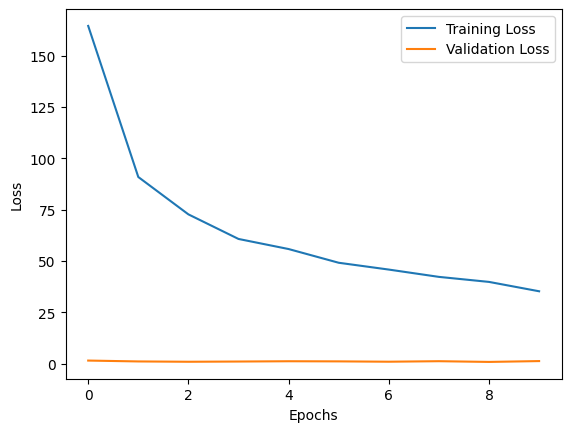

In [43]:
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

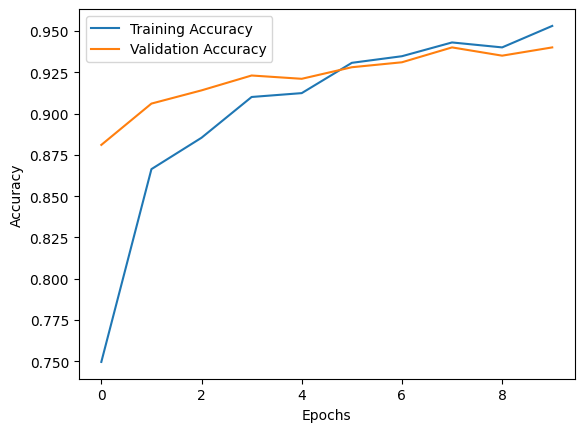

In [44]:
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()